In [1]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import cv2 # Sử dụng để lấy kích thước ảnh nếu cần

In [ ]:
import yaml

yaml_path = "data.yaml"  # Thay bằng đường dẫn của bạn
with open(yaml_path, 'r') as f:
    data_config = yaml.safe_load(f)

# Lấy danh sách tên class (mapping từ ID sang tên)
class_names = data_config.get('names', {})
print("Các lớp trong bộ dữ liệu:", class_names)

Các lớp trong bộ dữ liệu: ['Apple Scab Leaf', 'Apple leaf', 'Apple rust leaf', 'Bell_pepper leaf spot', 'Bell_pepper leaf', 'Blueberry leaf', 'Cherry leaf', 'Corn Gray leaf spot', 'Corn leaf blight', 'Corn rust leaf', 'Peach leaf', 'Potato leaf early blight', 'Potato leaf late blight', 'Potato leaf', 'Raspberry leaf', 'Soyabean leaf', 'Squash Powdery mildew leaf', 'Strawberry leaf', 'Tomato Early blight leaf', 'Tomato Septoria leaf spot', 'Tomato leaf bacterial spot', 'Tomato leaf late blight', 'Tomato leaf mosaic virus', 'Tomato leaf yellow virus', 'Tomato leaf', 'Tomato mold leaf', 'Tomato two spotted spider mites leaf', 'grape leaf black rot', 'grape leaf']


In [ ]:
def analyze_yolo_dataset(labels_dir, class_names):
    data_list = []
    
    # Tìm tất cả file .txt trong thư mục labels
    label_files = glob.glob(os.path.join(labels_dir, "*.txt"))
    
    total_images = len(label_files)
    total_objects = 0
    
    for file_path in label_files:
        filename = os.path.basename(file_path)
        
        with open(file_path, 'r') as f:
            lines = f.readlines()
            
        # Thống kê số lượng object trong ảnh này
        objects_in_image = len(lines)
        total_objects += objects_in_image
        
        for line in lines:
            parts = line.strip().split()
            if len(parts) == 5:
                class_id = int(parts[0])
                x_center = float(parts[1])
                y_center = float(parts[2])
                width = float(parts[3])
                height = float(parts[4])
                
                if 0 <= class_id < len(class_names):
                    class_name = class_names[class_id]
                else:
                    class_name = f"Unknown_{class_id}"
                
                data_list.append({
                    "filename": filename,
                    "class_id": class_id,
                    "class_name": class_name,
                    "x_center": x_center,
                    "y_center": y_center,
                    "bbox_width": width,
                    "bbox_height": height,
                    "bbox_area": width * height # Diện tích tương đối so với ảnh
                })
                
    df = pd.DataFrame(data_list)
    print(f"--- THỐNG KÊ SƠ BỘ ---")
    print(f"Tổng số ảnh có nhãn: {total_images}")
    print(f"Tổng số đối tượng (bounding boxes): {total_objects}")
    return df

# Chạy hàm (Thay đường dẫn tới thư mục labels, vì dữ liệu lớn nên ko đẩy lên github đc, ví dụ 'dataset/train/labels')
labels_path = "train/labels"
df_stats = analyze_yolo_dataset(labels_path, class_names)

--- THỐNG KÊ SƠ BỘ ---
Tổng số ảnh có nhãn: 250
Tổng số đối tượng (bounding boxes): 884



Số lượng đối tượng mỗi lớp:
class_name
Apple Scab Leaf                14
Apple leaf                     23
Apple rust leaf                39
Bell_pepper leaf               11
Blueberry leaf                140
Cherry leaf                     7
Corn Gray leaf spot             8
Corn leaf blight               48
Corn rust leaf                 15
Peach leaf                     47
Potato leaf                    26
Potato leaf late blight        33
Raspberry leaf                 58
Soyabean leaf                  13
Squash Powdery mildew leaf     13
Strawberry leaf                80
Tomato Early blight leaf       36
Tomato Septoria leaf spot      65
Tomato leaf                    42
Tomato leaf bacterial spot     38
Tomato leaf late blight        50
Tomato leaf mosaic virus       13
Tomato leaf yellow virus       19
Tomato mold leaf               15
grape leaf                      7
grape leaf black rot           24
Name: count, dtype: int64


C:\Users\DELL\AppData\Local\Temp\ipykernel_10960\462564777.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_stats, x='class_name', order=class_counts.index, palette='viridis')


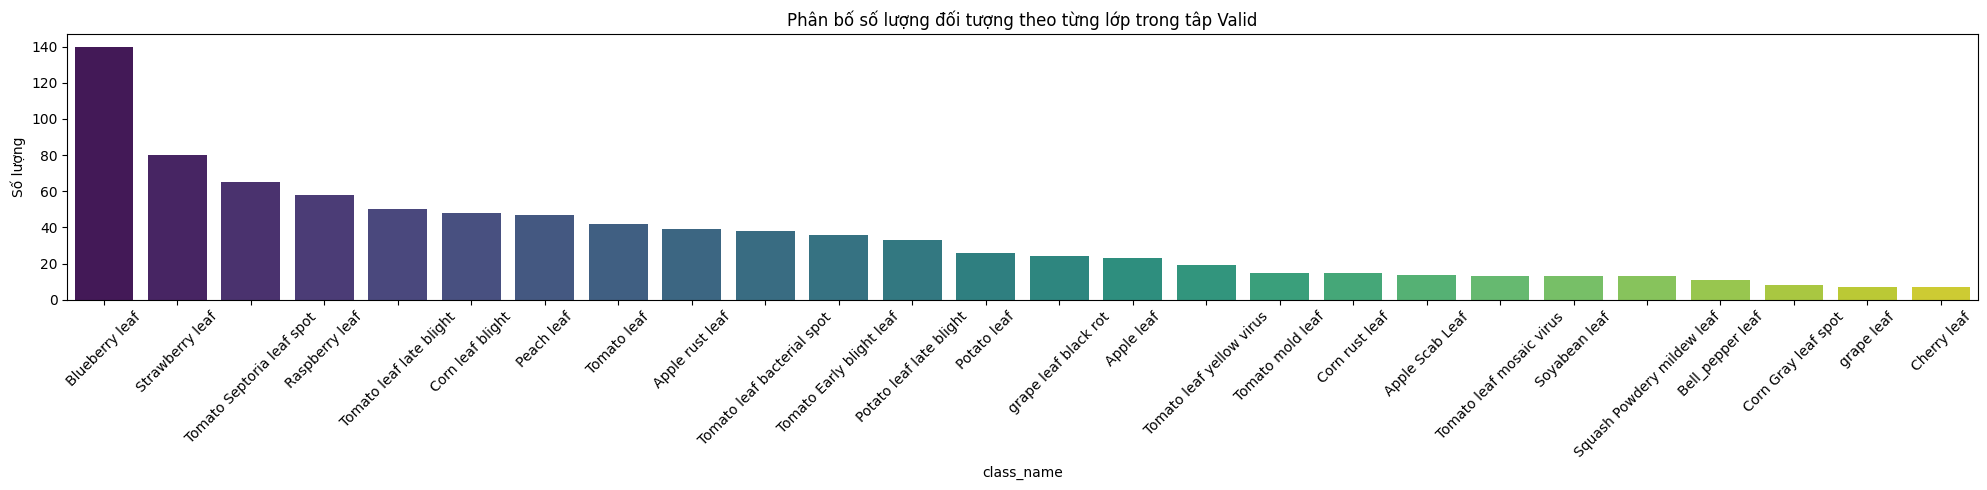

In [9]:
class_counts = df_stats['class_name'].value_counts()
print("\nSố lượng đối tượng mỗi lớp:")
print(class_counts.sort_index(ascending=True))

# Vẽ đồ thị barchart
plt.figure(figsize=(20, 5))
sns.countplot(data=df_stats, x='class_name', order=class_counts.index, palette='viridis')
plt.title('Phân bố số lượng đối tượng theo từng lớp trong tâp Valid')
plt.xticks(rotation=45)
plt.ylabel('Số lượng')
# plt.savefig('PhanBoDoiTuong_test_new.png', bbox_inches='tight')
plt.tight_layout()
plt.show()

In [ ]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yaml

# 1. Đọc file data.yaml để lấy tên class
yaml_path = "data.yaml"  # Thay bằng đường dẫn của bạn
with open(yaml_path, 'r') as f:
    data_config = yaml.safe_load(f)
raw_names = data_config.get('names', {})

# Nếu là list, chuyển nó thành dict. Nếu đã là dict rồi thì giữ nguyên.
if isinstance(raw_names, list):
    class_names = {i: name for i, name in enumerate(raw_names)}
else:
    class_names = raw_names

print("Các lớp trong bộ dữ liệu:", class_names)

dataset_paths = {
    "Train": "train/labels",
    "Valid": "valid/labels",
    "Test": "test/labels"
}

# 3. Hàm duyệt và gom dữ liệu
def collect_all_splits(paths_dict, class_names):
    all_data = []
    
    for split_name, labels_dir in paths_dict.items():
        if not os.path.exists(labels_dir):
            print(f"Cảnh báo: Không tìm thấy thư mục {labels_dir}, bỏ qua.")
            continue
            
        label_files = glob.glob(os.path.join(labels_dir, "*.txt"))
        print(f"Đang xử lý tập [{split_name}]: Tìm thấy {len(label_files)} file nhãn.")
        
        for file_path in label_files:
            filename = os.path.basename(file_path)
            
            with open(file_path, 'r') as f:
                lines = f.readlines()
                
            for line in lines:
                parts = line.strip().split()
                if len(parts) == 5:
                    class_id = int(parts[0])
                    
                    all_data.append({
                        "split": split_name, # Cột phân biệt tập Train/Test/Valid
                        "filename": filename,
                        "class_id": class_id,
                        "class_name": class_names.get(class_id, f"Unknown_{class_id}"),
                        "bbox_width": float(parts[3]),
                        "bbox_height": float(parts[4]),
                        "bbox_area": float(parts[3]) * float(parts[4])
                    })
                    
    return pd.DataFrame(all_data)

# Chạy hàm thu thập dữ liệu
df_all = collect_all_splits(dataset_paths, class_names)

Các lớp trong bộ dữ liệu: {0: 'Apple Scab Leaf', 1: 'Apple leaf', 2: 'Apple rust leaf', 3: 'Bell_pepper leaf spot', 4: 'Bell_pepper leaf', 5: 'Blueberry leaf', 6: 'Cherry leaf', 7: 'Corn Gray leaf spot', 8: 'Corn leaf blight', 9: 'Corn rust leaf', 10: 'Peach leaf', 11: 'Potato leaf early blight', 12: 'Potato leaf late blight', 13: 'Potato leaf', 14: 'Raspberry leaf', 15: 'Soyabean leaf', 16: 'Squash Powdery mildew leaf', 17: 'Strawberry leaf', 18: 'Tomato Early blight leaf', 19: 'Tomato Septoria leaf spot', 20: 'Tomato leaf bacterial spot', 21: 'Tomato leaf late blight', 22: 'Tomato leaf mosaic virus', 23: 'Tomato leaf yellow virus', 24: 'Tomato leaf', 25: 'Tomato mold leaf', 26: 'Tomato two spotted spider mites leaf', 27: 'grape leaf black rot', 28: 'grape leaf'}
Đang xử lý tập [Train]: Tìm thấy 2017 file nhãn.
Đang xử lý tập [Valid]: Tìm thấy 250 file nhãn.
Đang xử lý tập [Test]: Tìm thấy 249 file nhãn.


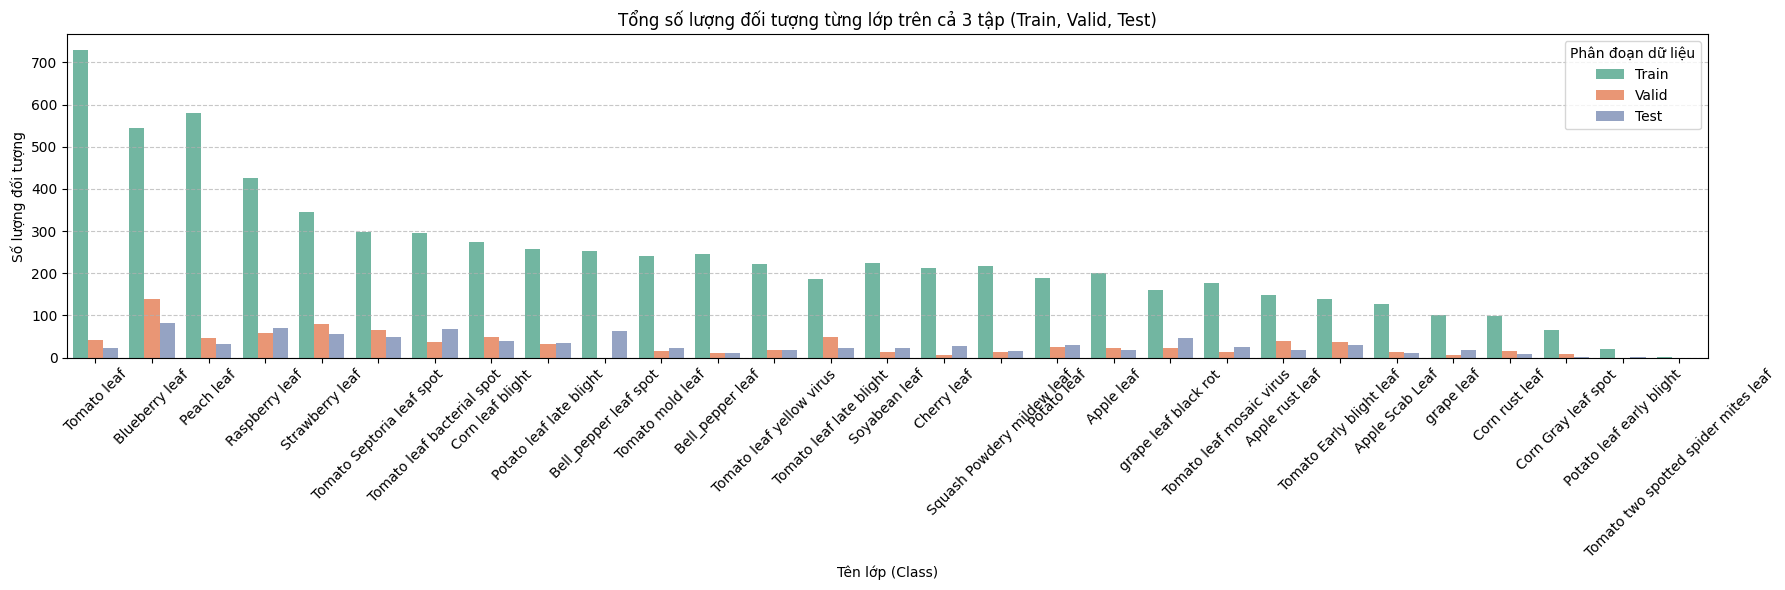

In [5]:
plt.figure(figsize=(18, 6))

# Sắp xếp các class theo số lượng từ nhiều đến ít
class_order = df_all['class_name'].value_counts().index

# Vẽ biểu đồ cột chồng (stacked) hoặc cột đôi nhờ tham số `hue`
sns.countplot(data=df_all, x='class_name', hue='split', order=class_order, palette='Set2')

plt.title('Tổng số lượng đối tượng từng lớp trên cả 3 tập (Train, Valid, Test)')
plt.xlabel('Tên lớp (Class)')
plt.ylabel('Số lượng đối tượng')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Phân đoạn dữ liệu')
plt.savefig('PhanBoDoiTuong_v12_new.png', bbox_inches='tight')
plt.tight_layout()
plt.show()

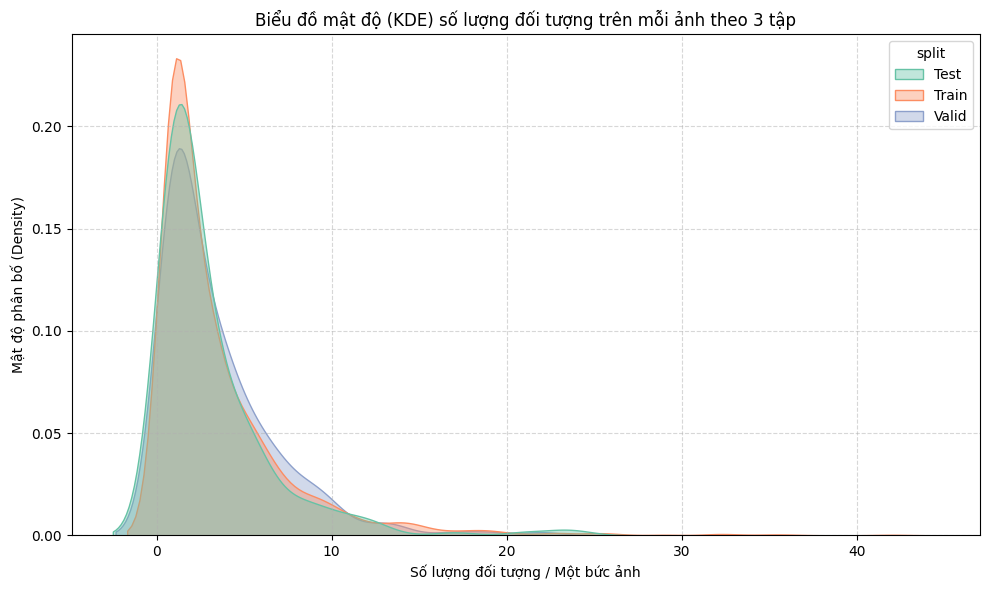

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Tính số lượng đối tượng (object count) trên từng ảnh của từng tập
# Nhóm theo 'split' và 'filename' rồi đếm số lượng hàng
objects_per_image = df_all.groupby(['split', 'filename']).size().reset_index(name='object_count')

# 2. Vẽ biểu đồ KDE (Kernel Density Estimate)
plt.figure(figsize=(10, 6))

sns.kdeplot(
    data=objects_per_image, 
    x='object_count', 
    hue='split', 
    fill=True,          # Tô màu vùng dưới đường cong
    common_norm=False,  # Chuẩn hóa độc lập từng tập để dễ so sánh tỷ lệ
    alpha=0.4,          # Độ trong suốt của màu tô
    palette='Set2'      # Bảng màu
)

plt.title('Biểu đồ mật độ (KDE) số lượng đối tượng trên mỗi ảnh theo 3 tập')
plt.xlabel('Số lượng đối tượng / Một bức ảnh')
plt.ylabel('Mật độ phân bố (Density)')
plt.grid(axis='both', linestyle='--', alpha=0.5)
plt.savefig('SoLuongDoiTuong_new.png', bbox_inches='tight')
plt.tight_layout()
plt.show()

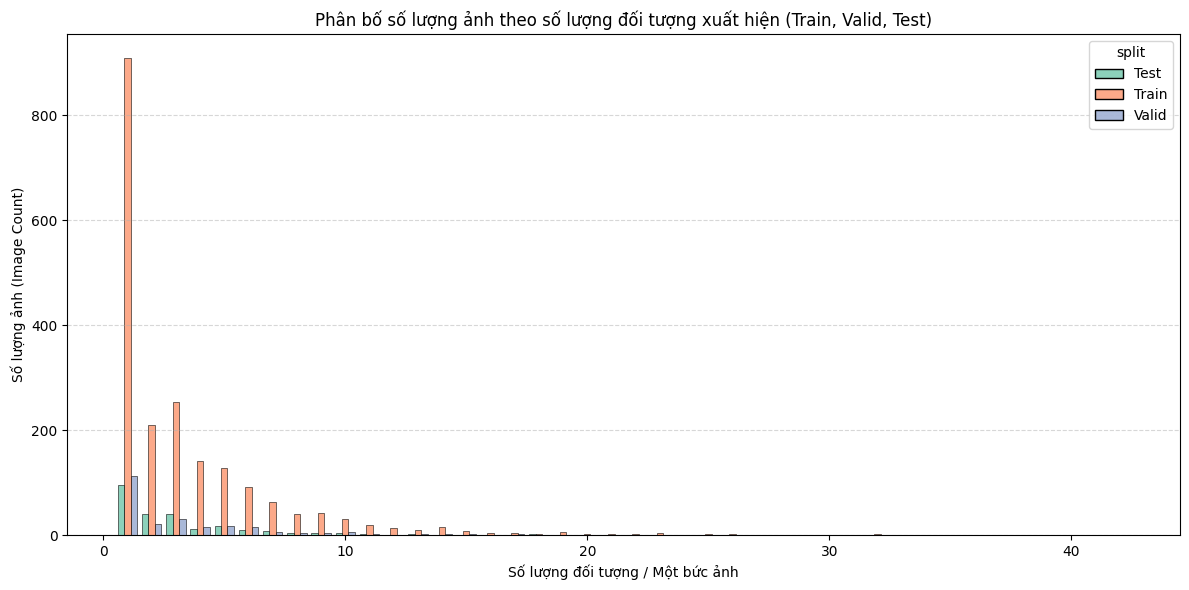

In [39]:
plt.figure(figsize=(12, 6))

# Vẽ biểu đồ Histogram cột ghép cạnh nhau (multiple="dodge")
sns.histplot(
    data=objects_per_image, 
    x='object_count', 
    hue='split', 
    multiple='dodge',   # Xếp các cột của 3 tập nằm cạnh nhau thay vì chồng lên nhau
    discrete=True,      # Biến số lượng đối tượng là số nguyên rời rạc
    shrink=0.8,         # Tạo khoảng cách nhỏ giữa các nhóm cột cho dễ nhìn
    palette='Set2'
)

plt.title('Phân bố số lượng ảnh theo số lượng đối tượng xuất hiện (Train, Valid, Test)')
plt.xlabel('Số lượng đối tượng / Một bức ảnh')
plt.ylabel('Số lượng ảnh (Image Count)')
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Nếu ảnh của bạn có quá nhiều vật thể (ví dụ từ 0 đến 50), 
# bạn có thể giới hạn trục X lại để biểu đồ không bị quá dài:
# plt.xlim(-0.5, 20) 

plt.tight_layout()
plt.show()